Adding a single sensor to a exponential component

The sensing accuracy is 71.43%


,t,test comp true state at time t,test comp sensed state at time t,s1 reading for time t,s1 true state at time t
0,0.0,0.0,0.0,0.0,0.0
1,0.5,0.0,0.0,0.0,0.0
2,1.0,0.0,1.0,1.0,1.0
3,1.5,0.0,0.0,0.0,0.0
4,2.0,0.0,0.0,0.0,0.0
5,2.5,0.0,0.0,0.0,0.0
6,3.0,0.0,1.0,1.0,1.0
7,3.5,0.0,0.0,0.0,0.0
8,4.0,0.0,0.0,0.0,0.0
9,4.5,0.0,1.0,1.0,1.0


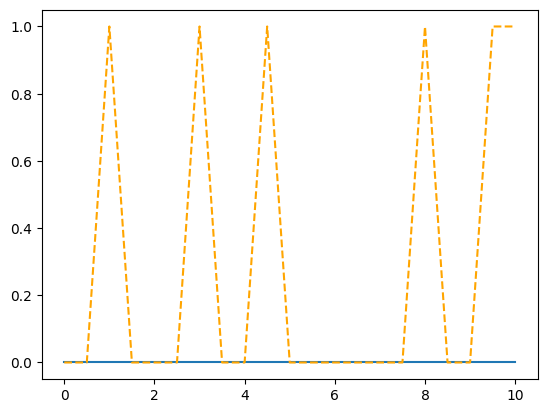

In [1]:
from sensor_objects.quality_based_sensor import QualityBasedSensor
from component_objects.component_exponential import ExponentialComponent
from sensed_objects.majority_vote_sensed_comp import MajorityVoteSensedComp

import matplotlib.pyplot as plt

# initialize comp and sensor 
comp = ExponentialComponent("test comp", MTTF= 5, MTTR=2)
sensor = QualityBasedSensor("s1", comp, quality= "Moderate")

sim_hours = 10
dt = 0.5
sensed_comp = MajorityVoteSensedComp(comp, [sensor])
sensed_comp.simulate(t_end=sim_hours, dt=dt)
sensed_comp.plot_history()

print(f"The sensing accuracy is {sum(sensor.history[:,1] / len(sensor.history)):.2%}")
sensed_comp.all_states

Sensed Comp with Multiple Sensors

,t,test comp true state at time t,test comp sensed state at time t,s0 reading for time t,s1 reading for time t,s2 reading for time t,s0 true state at time t,s1 true state at time t,s2 true state at time t
0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,3.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0
4,4.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
5,5.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
6,6.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7,7.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
8,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,9.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0


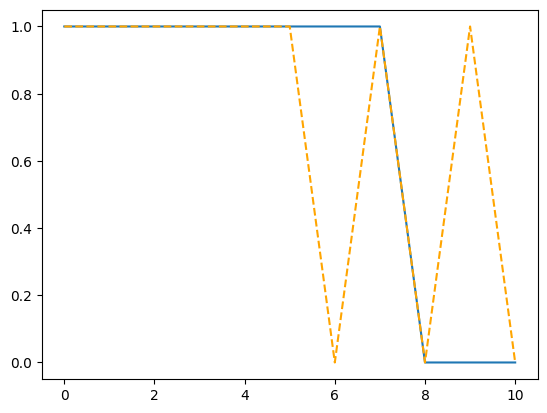

In [9]:
from sensor_objects.quality_based_sensor import QualityBasedSensor
from component_objects.component_exponential import ExponentialComponent
from sensed_objects.majority_vote_sensed_comp import MajorityVoteSensedComp

import matplotlib.pyplot as plt

# initialize comp and sensor 
comp = ExponentialComponent("test comp", MTTF= 5, MTTR=2)
num_sensors = 3
sensors = [QualityBasedSensor(f"s{i}", comp, quality= "Moderate") for i in range(num_sensors)]

sim_hours = 10
dt = 1
sensed_comp = MajorityVoteSensedComp(comp, sensors)
sensed_comp.simulate(t_end=sim_hours, dt=dt)
sensed_comp.plot_history()

# print(f"The sensing accuracy is {sum(sensor.history[:,1] / len(sensor.history)):.2%}")
sensed_comp.all_states

Comparing the accuracy of a Good vs Moderate vs Bad Single Sensor

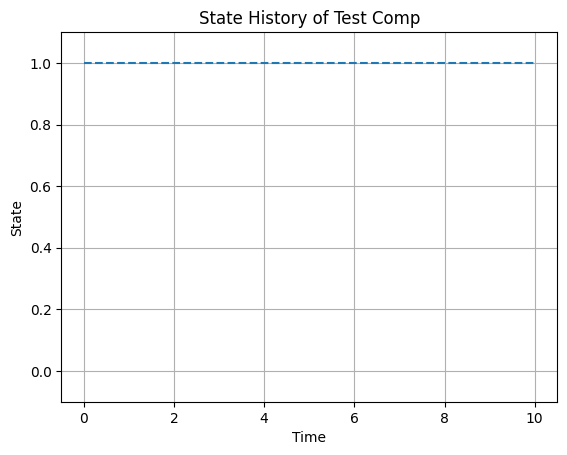

In [2]:
from sensor_objects.quality_based_sensor import QualityBasedSensor
from component_objects.component_exponential import ExponentialComponent
from component_objects.component_weibull import WeibullComponent

import matplotlib.pyplot as plt
import numpy as np

# initialize a common comp
comp = WeibullComponent("test comp", MTTF= 10, MTTR=2)

# initialize 3 different types of sensors
s1 = QualityBasedSensor("s_good", comp, quality= "Good")
s2 = QualityBasedSensor("s_moderate", comp, quality= "Moderate")
s3 = QualityBasedSensor("s_bad", comp, quality= "Bad")

# simulate history and read with all sensors
sim_hours = 10
dt = 0.5
comp.simulate(sim_hours, dt)
comp.plot_history()
# s1.simulate(sim_hours, dt)
# s2.simulate(sim_hours, dt)
# s3.simulate(sim_hours, dt)

# # check accuracy of each sensor
# accuracy1 = np.sum(s1.sensed_history[:,1] == comp.history[1:,1]) / len(comp.history)
# accuracy_times = np.sum(s1.sensed_history[:,0]== comp.history[1:,0])
# accuracy2 = np.sum(s2.sensed_history[:,1] == comp.history[1:,1]) / len(comp.history)
# accuracy3 = np.sum(s3.sensed_history[:,1] == comp.history[1:,1]) / len(comp.history)

# # print the accuracy of each sensor type 
# print(f"Good Sensor Accuracy = {accuracy1:.2%}")
# print(f"Moderate Sensor Accuracy = {accuracy2:.2%}")
# print(f"Bad Sensor Accuracy = {accuracy3:.2%}")

Checking the History vs. Sensed History of the sensors

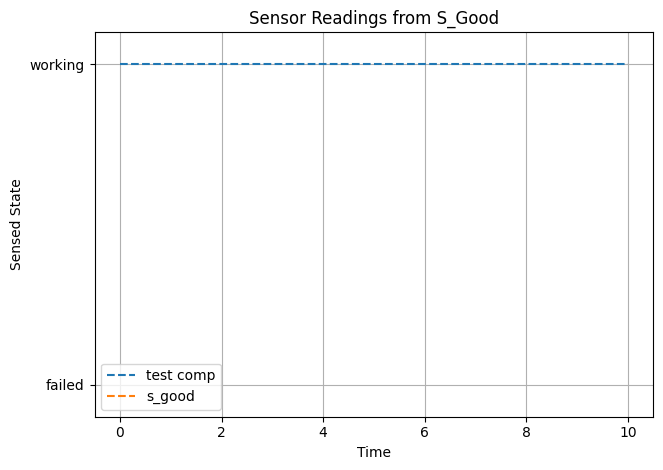

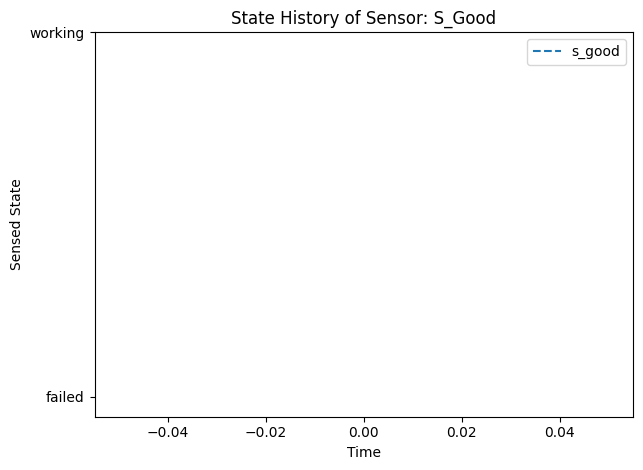

In [3]:
import matplotlib.pyplot as plt

plt.figure()
comp.plot_history()
s1.plot_history('sensed')

plt.figure()
s1.plot_history('truth')


Combined Sensor Readings for Multiple Moderate Sensors attached to one component

5


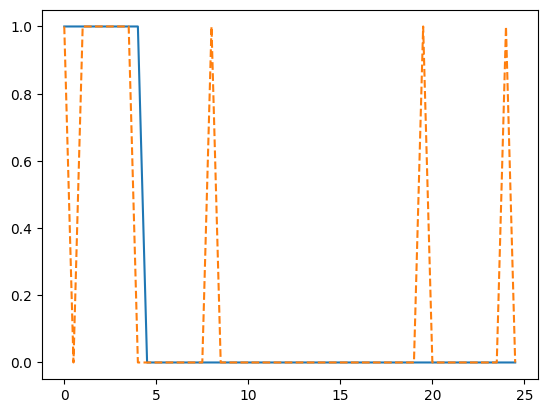

In [4]:
from sensor_objects.quality_based_sensor import QualityBasedSensor
from component_objects.component_exponential import ExponentialComponent
# from component_objects.component_weibull import WeibullComponent
from sensed_objects.majority_vote_sensed_comp import MajorityVoteSensedComp

import matplotlib.pyplot as plt

# initialize a component and multiple sensors
comp = ExponentialComponent("Comp w/ Multiple Sensors", MTTF=10, MTTR=2)
num_sensors = 5
sensors = [QualityBasedSensor(f"s{i+1}", comp, "Moderate") for i in range(num_sensors)]

# initialize the comp and sensors as a paired object
sc = MajorityVoteSensedComp(comp, sensors)

# attempt to simulate the sensed component and print the truth and sensed readings
sim_hours = 25
dt = 0.5
sc.simulate(sim_hours, dt)

plt.plot(sc.history[:,0], sc.history[:,1])
plt.plot(sc.sensed_history[:,0], sc.sensed_history[:,1], '--')